In [2]:
!pip install catboost

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:

df = pd.read_csv('data/grand_dAAAAAAaataset_final_scaled.csv')

In [6]:
 df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15875 entries, 0 to 15874
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   koi_disposition                 15875 non-null  str    
 1   koi_score                       15875 non-null  float64
 2   koi_period                      15875 non-null  float64
 3   koi_eccen                       15875 non-null  float64
 4   koi_impact                      15875 non-null  float64
 5   koi_duration                    15875 non-null  float64
 6   koi_depth                       15875 non-null  float64
 7   koi_ror                         15875 non-null  float64
 8   koi_srho                        15875 non-null  float64
 9   koi_incl                        15875 non-null  float64
 10  koi_teq                         15830 non-null  float64
 11  koi_insol                       15861 non-null  float64
 12  koi_dor                         15875 non-n

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [8]:
y = le.fit_transform(df["koi_disposition"])
X = df.drop("koi_disposition", axis=1)

In [9]:
for idx, label in enumerate(le.classes_):
    print(f"{idx}: {label}")

0: APC
1: CANDIDATE
2: CONFIRMED
3: FALSE POSITIVE


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15875 entries, 0 to 15874
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   koi_disposition                 15875 non-null  str    
 1   koi_score                       15875 non-null  float64
 2   koi_period                      15875 non-null  float64
 3   koi_eccen                       15875 non-null  float64
 4   koi_impact                      15875 non-null  float64
 5   koi_duration                    15875 non-null  float64
 6   koi_depth                       15875 non-null  float64
 7   koi_ror                         15875 non-null  float64
 8   koi_srho                        15875 non-null  float64
 9   koi_incl                        15875 non-null  float64
 10  koi_teq                         15830 non-null  float64
 11  koi_insol                       15861 non-null  float64
 12  koi_dor                         15875 non-n

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
cat_model = CatBoostClassifier(
    iterations=800, learning_rate=0.05, depth=8,
    loss_function='MultiClass', verbose=0
)

lgbm_model = LGBMClassifier(
    n_estimators=800, learning_rate=0.05, max_depth=8,
    objective='multiclass', random_state=42
)

models = {
    "CatBoost": cat_model,
    "LightGBM": lgbm_model
}

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import time

# Re-running with explicit progress tracking
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    start_time = time.time()
    print(f"\n🔹 Starting Cross-validation for {name}...")

    # n_jobs=-1 uses all available CPU cores to speed this up
    cv_results = cross_validate(model, X_train, y_train, cv=skf,
                                scoring=('accuracy', 'f1_macro'), n_jobs=-1)

    acc_mean = cv_results['test_accuracy'].mean()
    f1_mean = cv_results['test_f1_macro'].mean()

    elapsed = time.time() - start_time
    results[name] = {
        "Accuracy Mean": acc_mean,
        "F1 Macro Mean": f1_mean
    }
    print(f"✅ {name} Finished in {elapsed:.2f}s")
    print(f"Accuracy: {acc_mean:.4f} | F1-Macro: {f1_mean:.4f}")


🔹 Starting Cross-validation for CatBoost...
✅ CatBoost Finished in 37.46s
Accuracy: 0.7811 | F1-Macro: 0.6045

🔹 Starting Cross-validation for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12501
[LightGBM] [Info] Number of data points in the train set: 6350, number of used features: 51
[LightGBM] [Info] Start training from score -3.732330
[LightGBM] [Info] Start training from score -0.988523
[LightGBM] [Info] Start training from score -1.384092
[LightGBM] [Info] Start training from score -1.040195
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001305 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12501
[LightGBM] [Info] Number of data points in the train set: 6350, number of used features: 51
[LightGBM] [Info] Start training from score -3.732

In [15]:
best_model_name = max(results, key=lambda x: results[x]['F1 Macro Mean'])
best_model = models[best_model_name]
print(f"\n Best Model based on CV: {best_model_name}")


 Best Model based on CV: LightGBM


In [16]:
#fit the best model on the entire training set
best_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001699 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12501
[LightGBM] [Info] Number of data points in the train set: 12700, number of used features: 51
[LightGBM] [Info] Start training from score -3.732330
[LightGBM] [Info] Start training from score -0.988523
[LightGBM] [Info] Start training from score -1.384406
[LightGBM] [Info] Start training from score -1.039972
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,800
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [17]:
y_pred = best_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.07      0.11        76
           1       0.73      0.82      0.77      1182
           2       0.83      0.77      0.80       795
           3       0.87      0.85      0.86      1122

    accuracy                           0.80      3175
   macro avg       0.72      0.63      0.64      3175
weighted avg       0.80      0.80      0.79      3175


Confusion Matrix:
[[  5  51   6  14]
 [  3 973  87 119]
 [  1 172 611  11]
 [  2 143  28 949]]


In [18]:
decoded_preds = le.inverse_transform(y_pred.astype(int))
print(decoded_preds)

['CONFIRMED' 'CONFIRMED' 'FALSE POSITIVE' ... 'FALSE POSITIVE'
 'FALSE POSITIVE' 'CANDIDATE']


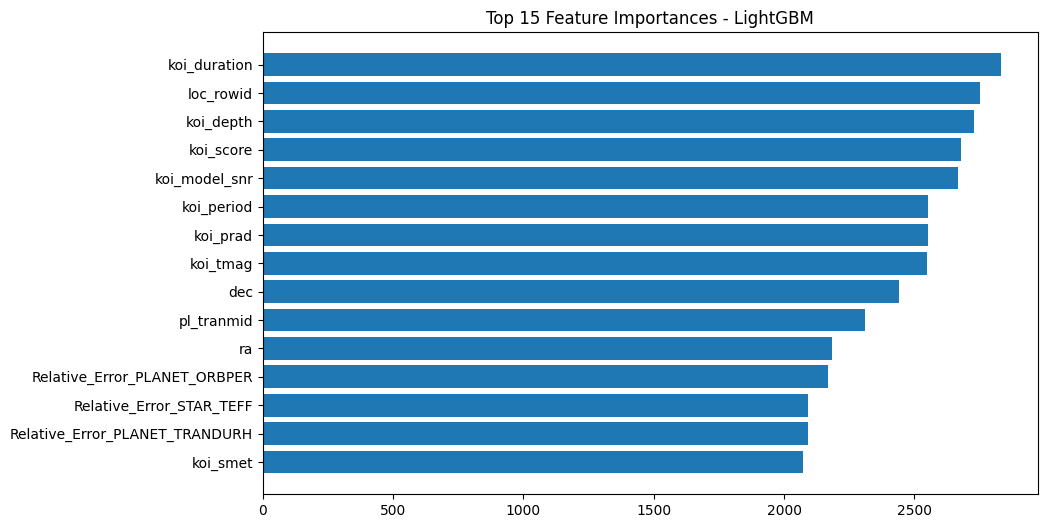

In [19]:
#Feature Importance Visualization
importance = best_model.feature_importances_
features = X.columns
fi = pd.DataFrame({"Feature": features, "Importance": importance}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(fi["Feature"].head(15)[::-1], fi["Importance"].head(15)[::-1])
plt.title(f"Top 15 Feature Importances - {best_model_name}")
plt.show()

In [20]:
# Create a new DataFrame df2 without the relative error columns
relative_error_cols = [
    'Relative_Error_PLANET_ORBPER',
    'Relative_Error_PLANET_RADE',
    'Relative_Error_PLANET_TRANDEP',
    'Relative_Error_PLANET_TRANDURH',
    'Relative_Error_PLANET_TRANMID',
    'Relative_Error_STAR_DIST',
    'Relative_Error_STAR_LOGG',
    'Relative_Error_STAR_PMDEC',
    'Relative_Error_STAR_PMRA',
    'Relative_Error_STAR_RAD',
    'Relative_Error_STAR_TEFF',
    'Relative_Error_STAR_TMAG'
]
df2 = df.drop(columns=relative_error_cols)


In [21]:
# Label encode target for df2
le2 = LabelEncoder()
y2 = le2.fit_transform(df2["koi_disposition"])
X2 = df2.drop("koi_disposition", axis=1)


In [22]:
# Train/test split for df2
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=42
)


In [23]:
# Reuse the same models for df2
results2 = {}
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    print(f"\n🔹 Cross-validating {name} (df2)...")
    acc_scores = cross_val_score(model, X2_train, y2_train, cv=skf2, scoring='accuracy')
    f1_scores = cross_val_score(model, X2_train, y2_train, cv=skf2, scoring='f1_macro')
    results2[name] = {
        "Accuracy Mean": acc_scores.mean(),
        "F1 Macro Mean": f1_scores.mean()
    }
    print(f"Accuracy: {acc_scores.mean():.4f} | F1-Macro: {f1_scores.mean():.4f}")



🔹 Cross-validating CatBoost (df2)...
Accuracy: 0.7872 | F1-Macro: 0.6126

🔹 Cross-validating LightGBM (df2)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9441
[LightGBM] [Info] Number of data points in the train set: 10160, number of used features: 39
[LightGBM] [Info] Start training from score -3.729045
[LightGBM] [Info] Start training from score -0.988734
[LightGBM] [Info] Start training from score -1.384721
[LightGBM] [Info] Start training from score -1.039749
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [24]:
import joblib
joblib.dump(best_model, f"{best_model_name}_exoplanet_model.pkl")

['LightGBM_exoplanet_model.pkl']

In [25]:
import joblib
print(list(X.columns))

['koi_score', 'koi_period', 'koi_eccen', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_ror', 'koi_srho', 'koi_incl', 'koi_teq', 'koi_insol', 'koi_dor', 'koi_model_snr', 'koi_count', 'koi_num_transits', 'koi_steff', 'koi_slogg', 'koi_smet', 'koi_smass', 'ra', 'dec', 'koi_kepmag', 'koi_gmag', 'koi_rmag', 'koi_imag', 'koi_zmag', 'koi_jmag', 'koi_hmag', 'koi_kmag', 'loc_rowid', 'st_pmra', 'st_pmdec', 'pl_tranmid', 'koi_prad', 'koi_tmag', 'st_dist', 'koi_srad', 'Relative_Error_PLANET_ORBPER', 'Relative_Error_PLANET_RADE', 'Relative_Error_PLANET_TRANDEP', 'Relative_Error_PLANET_TRANDURH', 'Relative_Error_PLANET_TRANMID', 'Relative_Error_STAR_DIST', 'Relative_Error_STAR_LOGG', 'Relative_Error_STAR_PMDEC', 'Relative_Error_STAR_PMRA', 'Relative_Error_STAR_RAD', 'Relative_Error_STAR_TEFF', 'Relative_Error_STAR_TMAG', 'koi_fittype_LS+MCMC', 'koi_fittype_MCMC', 'koi_fittype_none']


In [26]:
# Save the fitted LabelEncoder and feature list for API/testing use
import joblib
joblib.dump(le, "label_encoder.pkl")
joblib.dump(list(X.columns), "features.pkl")


['features.pkl']

In [27]:
!pip install optuna lightgbm scikit-learn joblib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 21.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.9/660.9 kB 12.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 12.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [optuna]2m7/8 [optuna]]my]


In [28]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, classification_report

/home/gluonparticle/Downloads/exoplanet_explorer-main/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
# 1. Load the Exact Dataset
print("Loading kepler_aligned.csv...")
df = pd.read_csv('data/kepler_aligned.csv')

# 2. Separate target and features
y_raw = df['koi_disposition']
X_raw = df.drop(columns=['koi_disposition'])

Loading kepler_aligned.csv...


In [30]:
# 3. Handle the Categorical 'koi_fittype' column
print("One-Hot Encoding 'koi_fittype' to fix the string-to-float error...")
X_encoded = pd.get_dummies(X_raw, columns=['koi_fittype'], drop_first=False)

# CRITICAL FIX: Replace the '+' in 'LS+MCMC' with an '_' so FastAPI doesn't crash
X_encoded.columns = X_encoded.columns.str.replace('+', '_')

# 4. Standard Scaling
print("Scaling numerical features for Neural Inference...")
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_encoded.columns)

# 5. V2.0 UPGRADE: KNN Imputation
print("Running KNN Imputation (k=5) to handle missing values...")
imputer = KNNImputer(n_neighbors=5, weights='distance')
X_clean_array = imputer.fit_transform(X_scaled)
X_clean = pd.DataFrame(X_clean_array, columns=X_scaled.columns)
print("Data is clean, scaled, and imputed.")

# 6. Encode Target Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

One-Hot Encoding 'koi_fittype' to fix the string-to-float error...
Scaling numerical features for Neural Inference...
Running KNN Imputation (k=5) to handle missing values...
Data is clean, scaled, and imputed.


In [31]:
# 7. V2.0 UPGRADE: Optuna Hyperparameter Tuning
def objective(trial):
    param = {
        'objective': 'multiclass',
        'num_class': len(le.classes_),
        'metric': 'multi_logloss',
        'verbosity': -1,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500)
    }
    model = lgb.LGBMClassifier(**param)
    model.fit(X_train, y_train)
    return accuracy_score(y_val, model.predict(X_val))

print("Executing Optuna Architecture Search (20 Trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(f"Best parameters found: {study.best_params}")

[I 2026-05-12 23:50:08,127] A new study created in memory with name: no-name-6508f687-bb0f-4d8b-9328-3e098d1cf894


Executing Optuna Architecture Search (20 Trials)...


[I 2026-05-12 23:50:12,564] Trial 0 finished with value: 0.8489951113525258 and parameters: {'learning_rate': 0.06018305301000449, 'num_leaves': 100, 'max_depth': 15, 'min_child_samples': 24, 'n_estimators': 135}. Best is trial 0 with value: 0.8489951113525258.
[I 2026-05-12 23:50:17,554] Trial 1 finished with value: 0.8549701249321021 and parameters: {'learning_rate': 0.01238692605307249, 'num_leaves': 44, 'max_depth': 12, 'min_child_samples': 44, 'n_estimators': 326}. Best is trial 1 with value: 0.8549701249321021.
[I 2026-05-12 23:50:21,631] Trial 2 finished with value: 0.8609451385116784 and parameters: {'learning_rate': 0.0416098107525637, 'num_leaves': 99, 'max_depth': 6, 'min_child_samples': 20, 'n_estimators': 375}. Best is trial 2 with value: 0.8609451385116784.
[I 2026-05-12 23:50:25,896] Trial 3 finished with value: 0.8598587724063009 and parameters: {'learning_rate': 0.05613176601876745, 'num_leaves': 38, 'max_depth': 11, 'min_child_samples': 35, 'n_estimators': 304}. Best 

Best parameters found: {'learning_rate': 0.0416098107525637, 'num_leaves': 99, 'max_depth': 6, 'min_child_samples': 20, 'n_estimators': 375}


In [32]:
print("Executing Optuna Architecture Search (20 Trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print(f"Best parameters found: {study.best_params}")

# 8. Train Final Model
print("Training Final Model...")
final_model = lgb.LGBMClassifier(**study.best_params, objective='multiclass', verbosity=-1)
final_model.fit(X_train, y_train)

# Evaluate
preds = final_model.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, preds) * 100:.2f}%")

# 9. Export Artifacts
print("Exporting files...")
joblib.dump(final_model, 'LightGBM_exoplanet_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(list(X_clean.columns), 'features.pkl')

# Re-attach the target column and save the final dataset for the UI
final_dataset = X_clean.copy()
final_dataset.insert(0, 'koi_disposition', y_raw.values)
final_dataset.to_csv('kepler_aligned_scaled.csv', index=False)

print("✅ DONE! Download the 3 .pkl files and 'kepler_aligned_scaled.csv'")

[I 2026-05-12 23:51:36,732] A new study created in memory with name: no-name-86352870-aa97-47eb-9cab-2a7175be63d4


Executing Optuna Architecture Search (20 Trials)...


[I 2026-05-12 23:51:46,038] Trial 0 finished with value: 0.8533405757740359 and parameters: {'learning_rate': 0.02875347701782988, 'num_leaves': 77, 'max_depth': 11, 'min_child_samples': 43, 'n_estimators': 389}. Best is trial 0 with value: 0.8533405757740359.
[I 2026-05-12 23:51:58,300] Trial 1 finished with value: 0.8479087452471483 and parameters: {'learning_rate': 0.012340829363230301, 'num_leaves': 84, 'max_depth': 15, 'min_child_samples': 11, 'n_estimators': 387}. Best is trial 0 with value: 0.8533405757740359.
[I 2026-05-12 23:52:01,885] Trial 2 finished with value: 0.8533405757740359 and parameters: {'learning_rate': 0.019493866971800018, 'num_leaves': 45, 'max_depth': 5, 'min_child_samples': 31, 'n_estimators': 484}. Best is trial 0 with value: 0.8533405757740359.
[I 2026-05-12 23:52:06,759] Trial 3 finished with value: 0.8565996740901684 and parameters: {'learning_rate': 0.0377540328870656, 'num_leaves': 80, 'max_depth': 14, 'min_child_samples': 40, 'n_estimators': 176}. Best

Best parameters found: {'learning_rate': 0.03854388841200269, 'num_leaves': 29, 'max_depth': 9, 'min_child_samples': 14, 'n_estimators': 389}
Training Final Model...
Accuracy: 85.93%
Exporting files...
✅ DONE! Download the 3 .pkl files and 'kepler_aligned_scaled.csv'
